In [21]:
# This cell imports the necessary libraries for data manipulation (pandas, numpy),
# visualization (matplotlib, seaborn), model building (sklearn.model_selection,
# sklearn.preprocessing, sklearn.linear_model, sklearn.ensemble), and model
# evaluation (sklearn.metrics).
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    classification_report
)

In [22]:
# This cell loads the diabetes dataset from a CSV file into a pandas DataFrame named `df`
# and then displays the first 5 rows of the DataFrame to quickly inspect the data.
df = pd.read_csv("/content/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [23]:
# This cell provides a summary of the DataFrame's structure, including data types
# and non-null counts (`df.info()`), and descriptive statistics for numerical
# columns (`df.describe()`). This helps in understanding the data distribution
# and identifying potential issues.
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [24]:
# This cell identifies columns where a value of `0` might indicate a missing or
# invalid entry (e.g., Glucose, BloodPressure, etc.) and replaces these `0` values
# with the median of their respective columns. This is a common strategy to handle
# missing data without removing rows or introducing bias from mean imputation.
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols_with_zero:
    df[col] = df[col].replace(0, df[col].median())

In [25]:
# This cell separates the features (independent variables, `X`) from the target
# variable (dependent variable, `y`), which is 'Outcome' (indicating diabetes
# presence). This is a standard step before training a machine learning model.
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [26]:
# This cell splits the dataset into training, validation, and test sets. The
# `train_test_split` function is used twice to achieve a 70/15/15 split.
# `stratify=y` ensures that the proportion of target classes (diabetic/non-diabetic)
# is maintained across all splits, which is important for imbalanced datasets.
# The sizes of the resulting sets are then printed.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set size:", X_train.shape)
print("Validation set size:", X_val.shape)
print("Test set size:", X_test.shape)

Training set size: (537, 8)
Validation set size: (115, 8)
Test set size: (116, 8)


In [27]:
# This cell initializes a `StandardScaler` to standardize the features. It then
# `fit_transforms` the training data and `transforms` the validation and test data.
# Standardization scales features to have zero mean and unit variance, which is
# crucial for many machine learning algorithms to perform optimally.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train);

X_val   = scaler.transform(X_val);
X_test  = scaler.transform(X_test);

In [28]:
# This cell initializes and trains a Logistic Regression model on the scaled
# training data. It then uses the trained model to make predictions (`lr_pred`)
# and predict probabilities (`lr_prob`) on the scaled test data.
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train);

lr_pred = lr_model.predict(X_test);

lr_prob = lr_model.predict_proba(X_test)[:, 1];

In [29]:
# This cell initializes and trains a Random Forest Classifier model on the scaled
# training data with 100 estimators and a fixed random state for reproducibility.
# It then uses the trained model to make predictions (`rf_pred`) and predict
# probabilities (`rf_prob`) on the scaled test data.
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train);

rf_pred = rf_model.predict(X_test);

rf_prob = rf_model.predict_proba(X_test)[:, 1];

In [30]:
# This cell defines a function `evaluate_model` to calculate and print various
# performance metrics for a given model, including Accuracy, Precision, Recall,
# F1 Score, ROC AUC, and a detailed Classification Report. This function will be
# used to assess the models' performance.
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"\n📊 Performance of {model_name}")
    print("-" * 40)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

In [31]:
# This cell defines a function `evaluate_model` to calculate and print various
# performance metrics for a given model, including Accuracy, Precision, Recall,
# F1 Score, ROC AUC, and a detailed Classification Report. This function will be
# used to assess the models' performance.
def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"\n📊 Performance of {model_name}")
    print("-" * 40)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred))

# This cell calls the `evaluate_model` function for both the Logistic Regression
# and Random Forest models, using the true test labels and the predictions/
# probabilities from each model. This outputs the performance metrics for comparison.
evaluate_model(y_test, lr_pred, lr_prob, "Logistic Regression");

evaluate_model(y_test, rf_pred, rf_prob, "Random Forest");


📊 Performance of Logistic Regression
----------------------------------------
Accuracy : 0.7844827586206896
Precision: 0.7857142857142857
Recall   : 0.5365853658536586
F1 Score : 0.6376811594202898
ROC AUC  : 0.863739837398374

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.92      0.85        75
           1       0.79      0.54      0.64        41

    accuracy                           0.78       116
   macro avg       0.78      0.73      0.74       116
weighted avg       0.78      0.78      0.77       116


📊 Performance of Random Forest
----------------------------------------
Accuracy : 0.7327586206896551
Precision: 0.6785714285714286
Recall   : 0.4634146341463415
F1 Score : 0.5507246376811594
ROC AUC  : 0.8302439024390244

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.88      0.81        75
           1       0.68      0.46      0.55        41

    accura

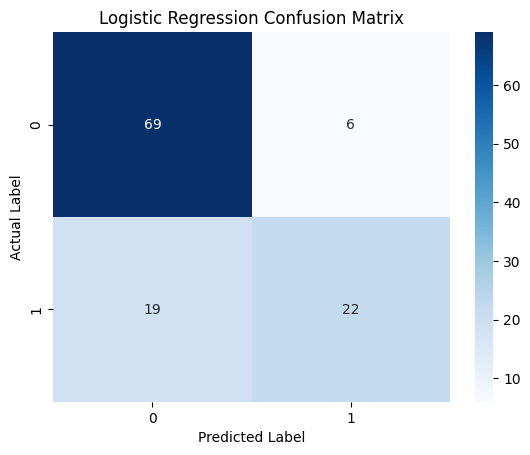

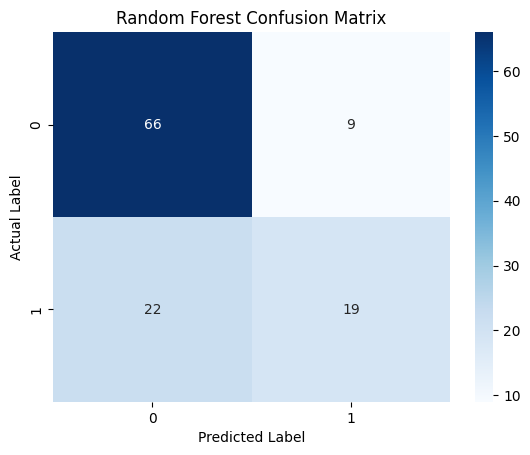

In [32]:
# This cell defines a function `plot_confusion_matrix` to visualize the confusion
# matrix for a given model. It then generates and displays confusion matrices for
# both the Logistic Regression and Random Forest models on the test set, providing
# a visual representation of true positives, true negatives, false positives,
# and false negatives.
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred);

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues');
    plt.xlabel("Predicted Label");
    plt.ylabel("Actual Label");
    plt.title(title);
    plt.show();

plot_confusion_matrix(y_test, lr_pred, "Logistic Regression Confusion Matrix");
plot_confusion_matrix(y_test, rf_pred, "Random Forest Confusion Matrix");

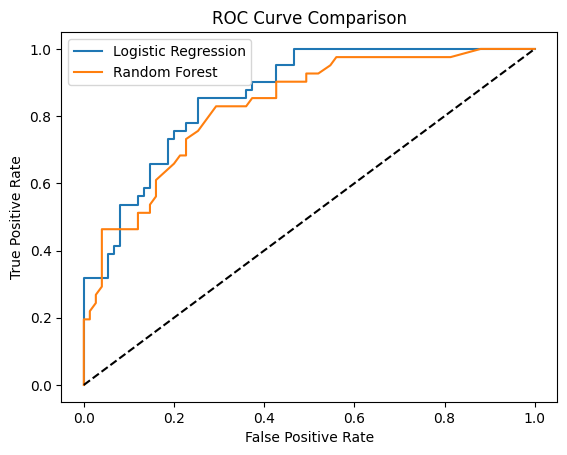

In [33]:
# This cell calculates the False Positive Rate (FPR) and True Positive Rate (TPR)
# for both Logistic Regression and Random Forest models using their predicted
# probabilities on the test set. It then plots these values to generate and compare
# their Receiver Operating Characteristic (ROC) curves, along with a diagonal line
# representing a random classifier. This helps visualize the trade-off between
# sensitivity and specificity.
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob);
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob);

plt.plot(lr_fpr, lr_tpr, label="Logistic Regression");
plt.plot(rf_fpr, rf_tpr, label="Random Forest");
plt.plot([0, 1], [0, 1], 'k--');

plt.xlabel("False Positive Rate");
plt.ylabel("True Positive Rate");
plt.title("ROC Curve Comparison");
plt.legend();
plt.show();

In [34]:
# This cell creates a pandas DataFrame to summarize the key performance metrics
# (Accuracy, F1 Score, ROC AUC) for both Logistic Regression and Random Forest models.
# This provides a clear, tabular comparison of the models' overall performance.
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, rf_prob)
    ]
});

results

,Model,Accuracy,F1 Score,ROC AUC
0,Logistic Regression,0.784483,0.637681,0.863740
1,Random Forest,0.732759,0.550725,0.830244


In [35]:
# This cell uses the `!pip install` command to install the `gradio` library,
# which is used for creating interactive web interfaces for machine learning models.
# The output shows that the requirement is already satisfied, meaning Gradio is
# already installed in the environment.
!pip install gradio

In [36]:
# This cell imports the `gradio` library as `gr`, making its functions and
# classes available for use in the notebook.
import gradio as gr

In [37]:
# This cell defines the `predict_diabetes` function, which serves as the core
# logic for the Gradio interface. It takes eight input parameters (representing
# patient data), scales them using the previously fitted `scaler`, makes a
# prediction using the trained Random Forest model (`rf_model`), and returns
# a human-readable result ('Diabetic' or 'Non-Diabetic').
def predict_diabetes(
    Pregnancies,
    Glucose,
    BloodPressure,
    SkinThickness,
    Insulin,
    BMI,
    DiabetesPedigreeFunction,
    Age
):
    input_data = pd.DataFrame([[
        Pregnancies,
        Glucose,
        BloodPressure,
        SkinThickness,
        Insulin,
        BMI,
        DiabetesPedigreeFunction,
        Age
    ]], columns=X.columns);

    input_scaled = scaler.transform(input_data);

    prediction = rf_model.predict(input_scaled)[0];

    if prediction == 1:
        return "⚠️ Diabetic"
    else:
        return "✅ Non-Diabetic"

In [38]:
# This cell creates a Gradio interface using `gr.Interface`. It specifies the
# `predict_diabetes` function as the model to be wrapped, defines the input
# components (numerical inputs with labels), sets the output component (a text box),
# and provides a title and description for the application.
interface = gr.Interface(
    fn=predict_diabetes,

    inputs=[
        gr.Number(label="Pregnancies"),
        gr.Number(label="Glucose Level"),
        gr.Number(label="Blood Pressure"),
        gr.Number(label="Skin Thickness"),
        gr.Number(label="Insulin Level"),
        gr.Number(label="BMI"),
        gr.Number(label="Diabetes Pedigree Function"),
        gr.Number(label="Age")
    ],

    outputs=gr.Textbox(label="Prediction Result"),

    title="Diabetes Prediction System",

    description=(
        "This application predicts whether a person is diabetic "
        "based on medical input parameters using a Machine Learning model."
        " \n\n Made By Daksh Kumar Sharma"
    )
)

In [39]:
# This cell launches the Gradio interface. When executed, it will typically
# generate a local URL and a public shareable URL, allowing users to interact
# with the deployed machine learning model through a web browser.
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d13956cc1c3fbad849.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
